# Task 5 · Capstone: redesign one chart for the human visual system

**Ali Afzal** · BSAI-7B-102 · Data Visualization · Week 2

**Dataset:** `gapminder.csv`, 142 countries × 12 years (1952–2007).

**The one question the chart must answer:** *Did any continent stop improving its life expectancy?*

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Paul Tol "bright" palette: stays distinct for colour-blind readers
RED, BLUE, GREY, INK = "#ee6677", "#4477aa", "#bbbbbb", "#333333"

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})


def save(fig, name):
    fig.savefig(CHARTS / name, dpi=300, bbox_inches="tight")

In [2]:
gm = pd.read_csv(DATA / "gapminder.csv")
print(f"{len(gm):,} rows, {gm.country.nunique()} countries, {gm.year.nunique()} years, "
      f"{gm.lifeExp.isna().sum()} missing life expectancies")
gm.groupby("continent").country.nunique().rename("countries")

1,704 rows, 142 countries, 12 years, 0 missing life expectancies


continent
Africa      52
Americas    25
Asia        33
Europe      30
Oceania      2
Name: countries, dtype: int64

## 1. The bad chart

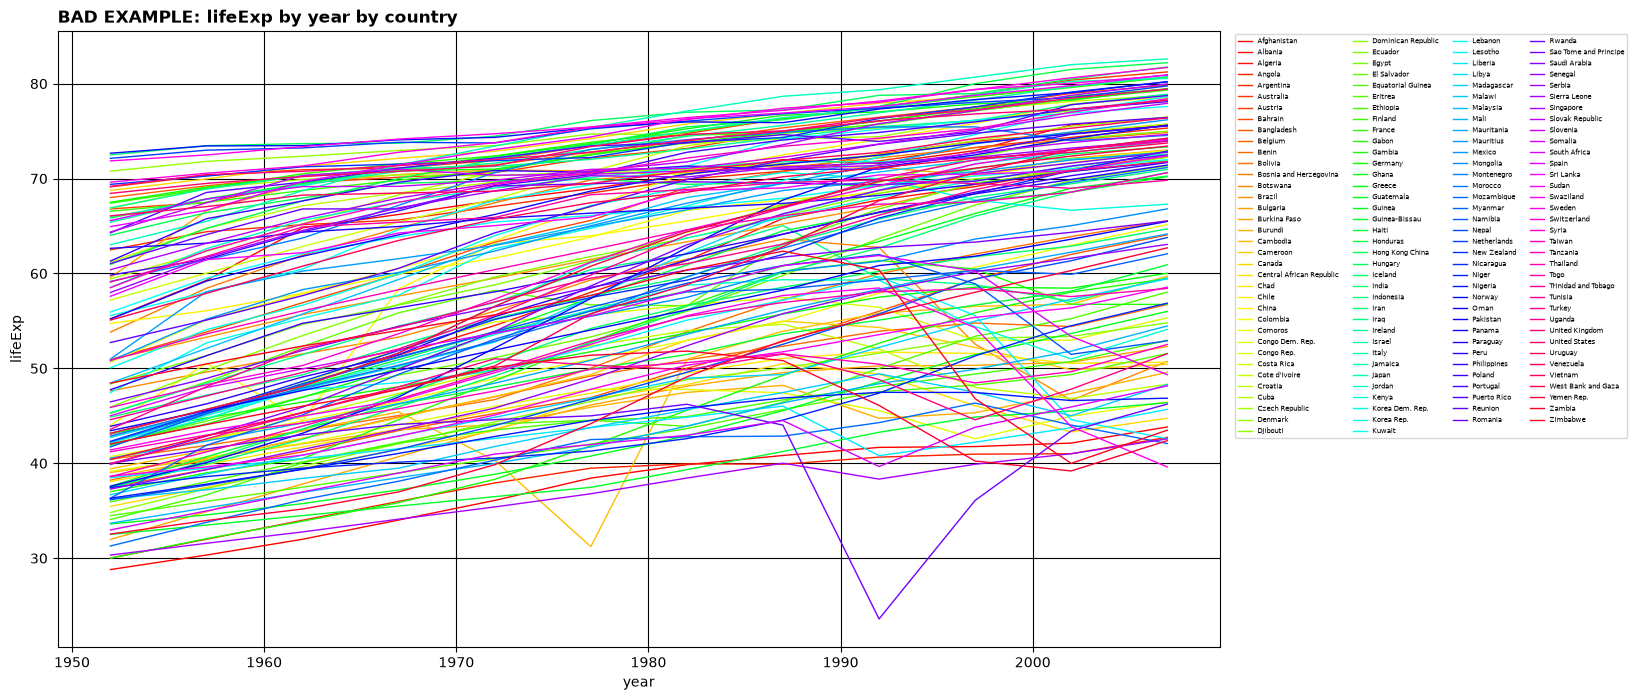

In [3]:
fig, ax = plt.subplots(figsize=(15, 8))
rainbow = plt.cm.hsv(np.linspace(0, 1, gm.country.nunique(), endpoint=False))
for colour, (country, d) in zip(rainbow, gm.groupby("country")):
    ax.plot(d.year, d.lifeExp, color=colour, lw=1, label=country)

ax.legend(ncol=4, fontsize=5, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.grid(True, color="black", linewidth=0.8)
for side in ax.spines.values():
    side.set_visible(True)
ax.set_xlabel("year")
ax.set_ylabel("lifeExp")
ax.set_title("BAD EXAMPLE: lifeExp by year by country")
save(fig, "t5_bad_spaghetti.png")

To answer *"did any continent stop improving?"* from this chart, you'd have to know which of the 142 rainbow
colours belong to which continent. The chart never shows continent at all.

## 2 + 4. Perception audit, before and after

| Row | Before: 142-line spaghetti | After: redesign below |
|---|---|---|
| **Preattentive** | **Hue** on 142 lines. Hue can keep about 6–8 categories apart, not 142, so it does no useful work. **Position** carries the data, but it's buried. | **Hue** used once: Africa is the only coloured line. **Line width** backs it up. **Position** carries every value. |
| **Pop-out** | Nothing, or noise: a bright yellow line, or Rwanda's 1992 dip. Neither is what the title says, and the title says nothing. | Africa's flat stretch from 1987 to 2002. That's exactly what the title claims. |
| **Gestalt** | Continuity wants to trace each line, but thousands of crossings break it. Similarity groups lines that are neighbours *in the rainbow*, not on the same continent. It groups the wrong things. | **Connection.** Each line joins one continent's 12 medians into a single object, so the reader sees 5 lines, not 60 points. The labels sit at the line ends, so no legend is needed. |
| **Cognitive load** | *Intrinsic:* 1,704 values. *Extraneous:* 142 hues, a 142-entry legend, a black grid, a full frame, an axis-name title. *Germane:* nothing protected. | *Intrinsic:* 5 continents × 12 years. *Extraneous removed:* legend, grid, frame, 137 lines. *Germane:* the one comparison that matters, Africa vs the rest. |
| **Channels** | life expectancy → y position (rank 1). year → x position (rank 1). country → hue (fine for categories, impossible at 142). **continent → not encoded at all.** | life expectancy → y position (rank 1). year → x position. continent → direct text label, and Africa also by hue and width. |
| **Working memory** | 142 colour-to-country pairs to hold. Far beyond 4 ± 1. | **2 chunks:** "the red line" and "the grey bundle". The labels are there for anyone who wants more detail. |

## 3. The rebuild

- **One line per continent, at the median country.** A single collapse, like Rwanda's 23.6 years in 1992,
  can't drag a median around.
- **Life expectancy on y position**, the most accurate channel for a quantity.
- **One pop-out:** Africa, in red and thicker. Everything else is grey.
- **Gestalt principle: connection.** Each line ties one continent's 12 years into a single object.
- **Not colour alone:** Africa is also the thickest line, and it's labelled by name.

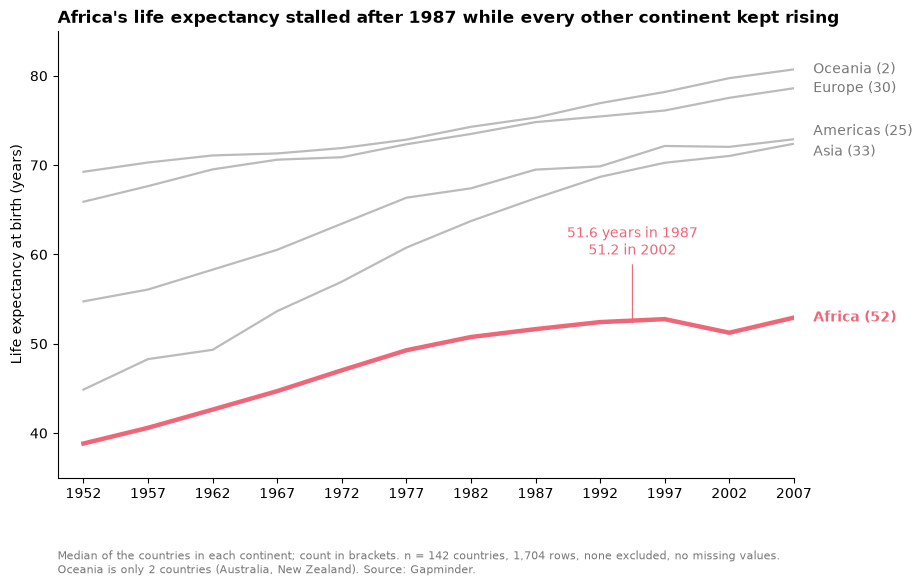

In [4]:
med = gm.groupby(["year", "continent"]).lifeExp.median().unstack()
countries = gm.groupby("continent").country.nunique()

LABEL_NUDGE = {"Americas": 0.9, "Asia": -0.9}   # their 2007 values are 0.5 years apart

fig, ax = plt.subplots(figsize=(9.5, 5.8))
for cont in med.columns:
    hot = cont == "Africa"
    ax.plot(med.index, med[cont], color=RED if hot else GREY, lw=3.2 if hot else 1.6,
            zorder=3 if hot else 2)
    y_end = med[cont].iloc[-1] + LABEL_NUDGE.get(cont, 0)
    ax.text(2008.5, y_end, f"{cont} ({countries[cont]})", va="center",
            color=RED if hot else "#777777", fontweight="bold" if hot else "normal")

a87, a02 = med.loc[1987, "Africa"], med.loc[2002, "Africa"]
ax.annotate(f"{a87:.1f} years in 1987\n{a02:.1f} in 2002", xy=(1994.5, a87 + 0.4),
            xytext=(1994.5, 60), ha="center", color=RED,
            arrowprops=dict(arrowstyle="-", color=RED, lw=0.8))

ax.set_xlim(1950, 2007)
ax.set_ylim(35, 85)
ax.set_xticks(range(1952, 2008, 5))
ax.set_ylabel("Life expectancy at birth (years)")
ax.set_title("Africa's life expectancy stalled after 1987 while every other continent kept rising")
ax.annotate("Median of the countries in each continent; count in brackets. n = 142 countries, "
            "1,704 rows, none excluded, no missing values.\nOceania is only 2 countries (Australia, "
            "New Zealand). Source: Gapminder.",
            xy=(0, -0.16), xycoords="axes fraction", fontsize=8, color="#777777", va="top")
save(fig, "perception_redesign.png")

**What the chart shows.** From 1952 to 1987, Africa's life expectancy climbed steadily, from 38.8 to 51.6
years. Then it stopped: 51.2 in 2002 and 52.9 in 2007. Over the same twenty years every grey line kept
rising, by 3 to 6 years. The gap between Africa and Asia grew from 15 years in 1987 to almost 20 in 2007.

The y axis starts at 35, not 0. These are lines, and the message is in their slope. A zero baseline would
flatten every line and hide the stall.

## 5. Test it on a human

I showed the redesign, and not the original, to someone who hadn't seen the data, and asked: **"In one
sentence, what does this show?"**

> **Reader:** *(first name or "a classmate")*
>
> **Their sentence, word for word:** *"…"*

**Does it match my title?** *(Yes or no. If no: which part misled them, and what I'd change next.)*

## The question: what the redesign makes harder to see

In [5]:
wide = gm.pivot(index="country", columns="year", values="lifeExp")
change = (wide[2002] - wide[1987]).rename("change_1987_2002")
africa = gm.drop_duplicates("country").set_index("country").continent == "Africa"

fell = change[africa & (change < 0)].sort_values()
rose = change[africa & (change > 0)].sort_values(ascending=False)
print(f"{len(fell)} of {africa.sum()} African countries LOST life expectancy between 1987 and 2002.")
print(f"Worst: {fell.index[0]} ({fell.iloc[0]:+.1f} years). "
      f"Meanwhile {rose.index[0]} gained {rose.iloc[0]:+.1f}.")

low = gm.loc[gm.lifeExp.idxmin()]
print(f"Lowest value in the whole file: {low.country}, {low.year}: {low.lifeExp:.1f} years.")

22 of 52 African countries LOST life expectancy between 1987 and 2002.
Worst: Zimbabwe (-22.4 years). Meanwhile Egypt gained +10.0.
Lowest value in the whole file: Rwanda, 1992: 23.6 years.


**It hides the countries.** The median of 52 African countries is one tidy line, but the real story has a
wide spread. 22 of those countries *lost* years between 1987 and 2002, Zimbabwe more than 22 of them, while
others kept gaining. The red line averages out both the collapse and the success. Rwanda's 23.6 years in
1992, the lowest point in the whole dataset, has disappeared completely.

Greying the other continents costs something too: the Americas and Asia now look like one bundle, although
Asia climbed much faster. That's the trade. The chart answers *"did any continent stall?"* in one glance, and
anyone asking *"which countries?"* needs a different chart.

## Self-audit

- [x] Every chart built with `fig, ax` (no `plt.plot` / `plt.bar`)
- [x] Exactly one pop-out element, and it carries the title's message
- [x] The Gestalt principle used is named in the notebook (connection)
- [x] Most important variable on the highest-ranking available channel (life expectancy → y position)
- [x] Every element classified as intrinsic / extraneous / germane (audit table)
- [x] Reader never holds more than ~4 chunks at once (2: red line, grey bundle)
- [x] No information carried by colour alone (Africa is also thicker and labelled)
- [x] Context greyed, message coloured
- [x] `n` and exclusions declared on the figure
- [x] Title states a finding
- [ ] A real reader's one-sentence reading is recorded verbatim *(step 5)*